In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data =  pd.read_csv(r"C:\Users\Sahil Sundhan\Documents\ss_projects\PythonPractice\math-for-data-science\Clustring\Hotel Reservations.csv")

In [3]:
# We have a data of hotel reservations
# Use it for clustering customer bookings to identify patterns

# Step 1: Understand and explore the data

In [4]:
data.head(100)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,INN00096,2,1,0,2,Meal Plan 1,1,Room_Type 1,134,2018,8,4,Online,0,0,0,130.50,2,Not_Canceled
96,INN00097,2,0,0,2,Meal Plan 2,0,Room_Type 1,320,2018,8,18,Online,0,0,0,115.00,1,Canceled
97,INN00098,2,0,0,4,Meal Plan 1,0,Room_Type 1,118,2018,4,13,Online,0,0,0,90.95,1,Not_Canceled
98,INN00099,2,0,0,3,Meal Plan 1,0,Room_Type 1,30,2018,11,17,Online,0,0,0,76.08,1,Not_Canceled


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [7]:
data.describe(include ='all')

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
count,36275,36275.000000,36275.000000,36275.000000,36275.000000,36275,36275.000000,36275,36275.000000,36275.000000,36275.000000,36275.000000,36275,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275
unique,36275,NaN,NaN,NaN,NaN,4,NaN,7,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,2
top,INN00001,NaN,NaN,NaN,NaN,Meal Plan 1,NaN,Room_Type 1,NaN,NaN,NaN,NaN,Online,NaN,NaN,NaN,NaN,NaN,Not_Canceled
freq,1,NaN,NaN,NaN,NaN,27835,NaN,28130,NaN,NaN,NaN,NaN,23214,NaN,NaN,NaN,NaN,NaN,24390
mean,NaN,1.844962,0.105279,0.810724,2.204300,NaN,0.030986,NaN,85.232557,2017.820427,7.423653,15.596995,NaN,0.025637,0.023349,0.153411,103.423539,0.619655,NaN
std,NaN,0.518715,0.402648,0.870644,1.410905,NaN,0.173281,NaN,85.930817,0.383836,3.069894,8.740447,NaN,0.158053,0.368331,1.754171,35.089424,0.786236,NaN
min,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,0.000000,2017.000000,1.000000,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,2.000000,0.000000,0.000000,1.000000,NaN,0.000000,NaN,17.000000,2018.000000,5.000000,8.000000,NaN,0.000000,0.000000,0.000000,80.300000,0.000000,NaN
50%,NaN,2.000000,0.000000,1.000000,2.000000,NaN,0.000000,NaN,57.000000,2018.000000,8.000000,16.000000,NaN,0.000000,0.000000,0.000000,99.450000,0.000000,NaN
75%,NaN,2.000000,0.000000,2.000000,3.000000,NaN,0.000000,NaN,126.000000,2018.000000,10.000000,23.000000,NaN,0.000000,0.000000,0.000000,120.000000,1.000000,NaN


In [8]:
print(data['type_of_meal_plan'].value_counts())

type_of_meal_plan
Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64


In [9]:
print(data['room_type_reserved'].value_counts())

room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64


In [10]:
print(data['market_segment_type'].value_counts())

market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64


In [11]:
print(data['booking_status'].value_counts())

booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64


In [12]:
print(data['required_car_parking_space'].value_counts())

required_car_parking_space
0    35151
1     1124
Name: count, dtype: int64


In [13]:
print(data['repeated_guest'].value_counts())

repeated_guest
0    35345
1      930
Name: count, dtype: int64


In [14]:
print(data['no_of_previous_bookings_not_canceled'].value_counts().head(10))
# As there are only ~3% repeat customers using previous booking data is not significant

no_of_previous_bookings_not_canceled
0     35463
1       228
2       112
3        80
4        65
5        60
6        36
7        24
8        23
10       19
Name: count, dtype: int64


In [15]:
print(data['no_of_adults'].value_counts())

no_of_adults
2    26108
1     7695
3     2317
0      139
4       16
Name: count, dtype: int64


In [16]:
print(data['no_of_children'].value_counts())
#Number of children 9 and 10 looks like outlier

no_of_children
0     33577
1      1618
2      1058
3        19
9         2
10        1
Name: count, dtype: int64


In [18]:
#oulier removal
data = data[data['no_of_children']<=3]
data.reset_index(inplace=True)

In [19]:
print(data.columns)

Index(['level_0', 'index', 'Booking_ID', 'no_of_adults', 'no_of_children',
       'no_of_weekend_nights', 'no_of_week_nights', 'type_of_meal_plan',
       'required_car_parking_space', 'room_type_reserved', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'market_segment_type',
       'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'booking_status'],
      dtype='object')


In [20]:
numerical_features = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time','repeated_guest',
       'avg_price_per_room', 'no_of_special_requests']

In [21]:
categorical_features  = ['type_of_meal_plan','room_type_reserved','market_segment_type']


In [22]:
data_features = data[numerical_features + categorical_features + ['booking_status']  ]
data_features.head(10)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,repeated_guest,avg_price_per_room,no_of_special_requests,type_of_meal_plan,room_type_reserved,market_segment_type,booking_status
0,2,0,1,2,0,224,0,65.00,0,Meal Plan 1,Room_Type 1,Offline,Not_Canceled
1,2,0,2,3,0,5,0,106.68,1,Not Selected,Room_Type 1,Online,Not_Canceled
2,1,0,2,1,0,1,0,60.00,0,Meal Plan 1,Room_Type 1,Online,Canceled
3,2,0,0,2,0,211,0,100.00,0,Meal Plan 1,Room_Type 1,Online,Canceled
4,2,0,1,1,0,48,0,94.50,0,Not Selected,Room_Type 1,Online,Canceled
5,2,0,0,2,0,346,0,115.00,1,Meal Plan 2,Room_Type 1,Online,Canceled
6,2,0,1,3,0,34,0,107.55,1,Meal Plan 1,Room_Type 1,Online,Not_Canceled
7,2,0,1,3,0,83,0,105.61,1,Meal Plan 1,Room_Type 4,Online,Not_Canceled
8,3,0,0,4,0,121,0,96.90,1,Meal Plan 1,Room_Type 1,Offline,Not_Canceled
9,2,0,0,5,0,44,0,133.44,3,Meal Plan 1,Room_Type 4,Online,Not_Canceled


In [21]:
data.repeated_guest.value_counts()

0    35342
1      930
Name: repeated_guest, dtype: int64

# Step 2: Create features from the data

In [23]:
x_train  = data_features[numerical_features + categorical_features]

# There is nothing to predict in clustering
# We are just storing booking status flag in another variable to 
# check later if the clusters have some pattern w.r.t booking cancellation
y_label = data_features[['booking_status']]

In [25]:
x_train = pd.get_dummies(x_train, columns =categorical_features, drop_first= False)
print(x_train.columns)

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'repeated_guest', 'avg_price_per_room', 'no_of_special_requests',
       'type_of_meal_plan_Meal Plan 1', 'type_of_meal_plan_Meal Plan 2',
       'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected',
       'room_type_reserved_Room_Type 1', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Aviation',
       'market_segment_type_Complementary', 'market_segment_type_Corporate',
       'market_segment_type_Offline', 'market_segment_type_Online'],
      dtype='object')


In [26]:
x_train.head(10)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,repeated_guest,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 1,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,0,65.00,0,True,...,False,False,False,False,False,False,False,False,True,False
1,2,0,2,3,0,5,0,106.68,1,False,...,False,False,False,False,False,False,False,False,False,True
2,1,0,2,1,0,1,0,60.00,0,True,...,False,False,False,False,False,False,False,False,False,True
3,2,0,0,2,0,211,0,100.00,0,True,...,False,False,False,False,False,False,False,False,False,True
4,2,0,1,1,0,48,0,94.50,0,False,...,False,False,False,False,False,False,False,False,False,True
5,2,0,0,2,0,346,0,115.00,1,False,...,False,False,False,False,False,False,False,False,False,True
6,2,0,1,3,0,34,0,107.55,1,True,...,False,False,False,False,False,False,False,False,False,True
7,2,0,1,3,0,83,0,105.61,1,True,...,False,True,False,False,False,False,False,False,False,True
8,3,0,0,4,0,121,0,96.90,1,True,...,False,False,False,False,False,False,False,False,True,False
9,2,0,0,5,0,44,0,133.44,3,True,...,False,True,False,False,False,False,False,False,False,True


# Step 3: Scale the data

In [27]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_train[numerical_features] = scaler.fit_transform(x_train[numerical_features])
x_train.describe()
x_train_copy = x_train.copy()

In [28]:
x_train

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,repeated_guest,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 1,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,0.50,0.0,0.142857,0.117647,0.0,0.505643,0.0,0.120370,0.0,True,...,False,False,False,False,False,False,False,False,True,False
1,0.50,0.0,0.285714,0.176471,0.0,0.011287,0.0,0.197556,0.2,False,...,False,False,False,False,False,False,False,False,False,True
2,0.25,0.0,0.285714,0.058824,0.0,0.002257,0.0,0.111111,0.0,True,...,False,False,False,False,False,False,False,False,False,True
3,0.50,0.0,0.000000,0.117647,0.0,0.476298,0.0,0.185185,0.0,True,...,False,False,False,False,False,False,False,False,False,True
4,0.50,0.0,0.142857,0.058824,0.0,0.108352,0.0,0.175000,0.0,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36267,0.75,0.0,0.285714,0.352941,0.0,0.191874,0.0,0.310741,0.2,True,...,False,True,False,False,False,False,False,False,False,True
36268,0.50,0.0,0.142857,0.176471,0.0,0.514673,0.0,0.168426,0.4,True,...,False,False,False,False,False,False,False,False,False,True
36269,0.50,0.0,0.285714,0.352941,0.0,0.334086,0.0,0.182204,0.4,True,...,False,False,False,False,False,False,False,False,False,True
36270,0.50,0.0,0.000000,0.176471,0.0,0.142212,0.0,0.175000,0.0,False,...,False,False,False,False,False,False,False,False,False,True


In [29]:
x_train_copy.to_csv("x_train.csv",index= False)

# Step 4: Apply kmeans clustering

In [30]:
from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=10, random_state=0, n_init="auto").fit(x_train)
x_train['cluster_labels'] = kmeans.labels_
x_train['booking_status'] = y_label['booking_status']



In [31]:
from sklearn.metrics import silhouette_score
silhouette_score(x_train_copy, kmeans.labels_)

0.6197901139544487

In [32]:
x_train['cluster_labels'].value_counts()

cluster_labels
2    10747
1     7387
4     5974
3     5071
7     2374
5     2230
8      878
6      866
9      656
0       89
Name: count, dtype: int64

# Step 5: Understand the patterns in clusters

In [33]:
x_train['booking_status'].value_counts()

booking_status
Not_Canceled    24388
Canceled        11884
Name: count, dtype: int64

In [34]:
print("cancellation rate in data:", 100*11884/(11884 + 24388))

cancellation rate in data: 32.763564181737976


In [35]:
cluster_number = []
cancellation_rate = []

for z in range(len(list(x_train['cluster_labels'].unique()))):
               cluster_number.append(z)
               temp = x_train[x_train['cluster_labels']==z]
               temp_cancelled = temp[temp['booking_status']=='Canceled']
               temp_not_cancelled = temp[temp['booking_status']=='Not_Canceled']
               cancel = (len(temp_cancelled)/len(temp))*100
               cancellation_rate.append(cancel)
               

<Axes: xlabel='cluster', ylabel='cancellation'>

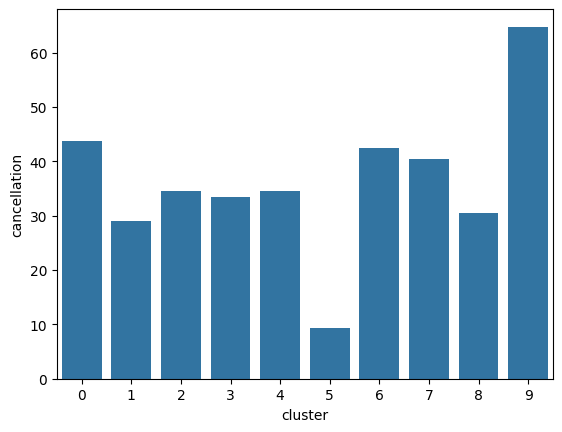

In [36]:
temp = pd.DataFrame({'cluster':cluster_number, 'cancellation': cancellation_rate})
sns.barplot(x = 'cluster',y = 'cancellation', data = temp)

In [37]:
data['cluster'] = kmeans.labels_
data.to_csv('clustering_results.csv')

In [36]:
# Check average value of numerical features across clusters

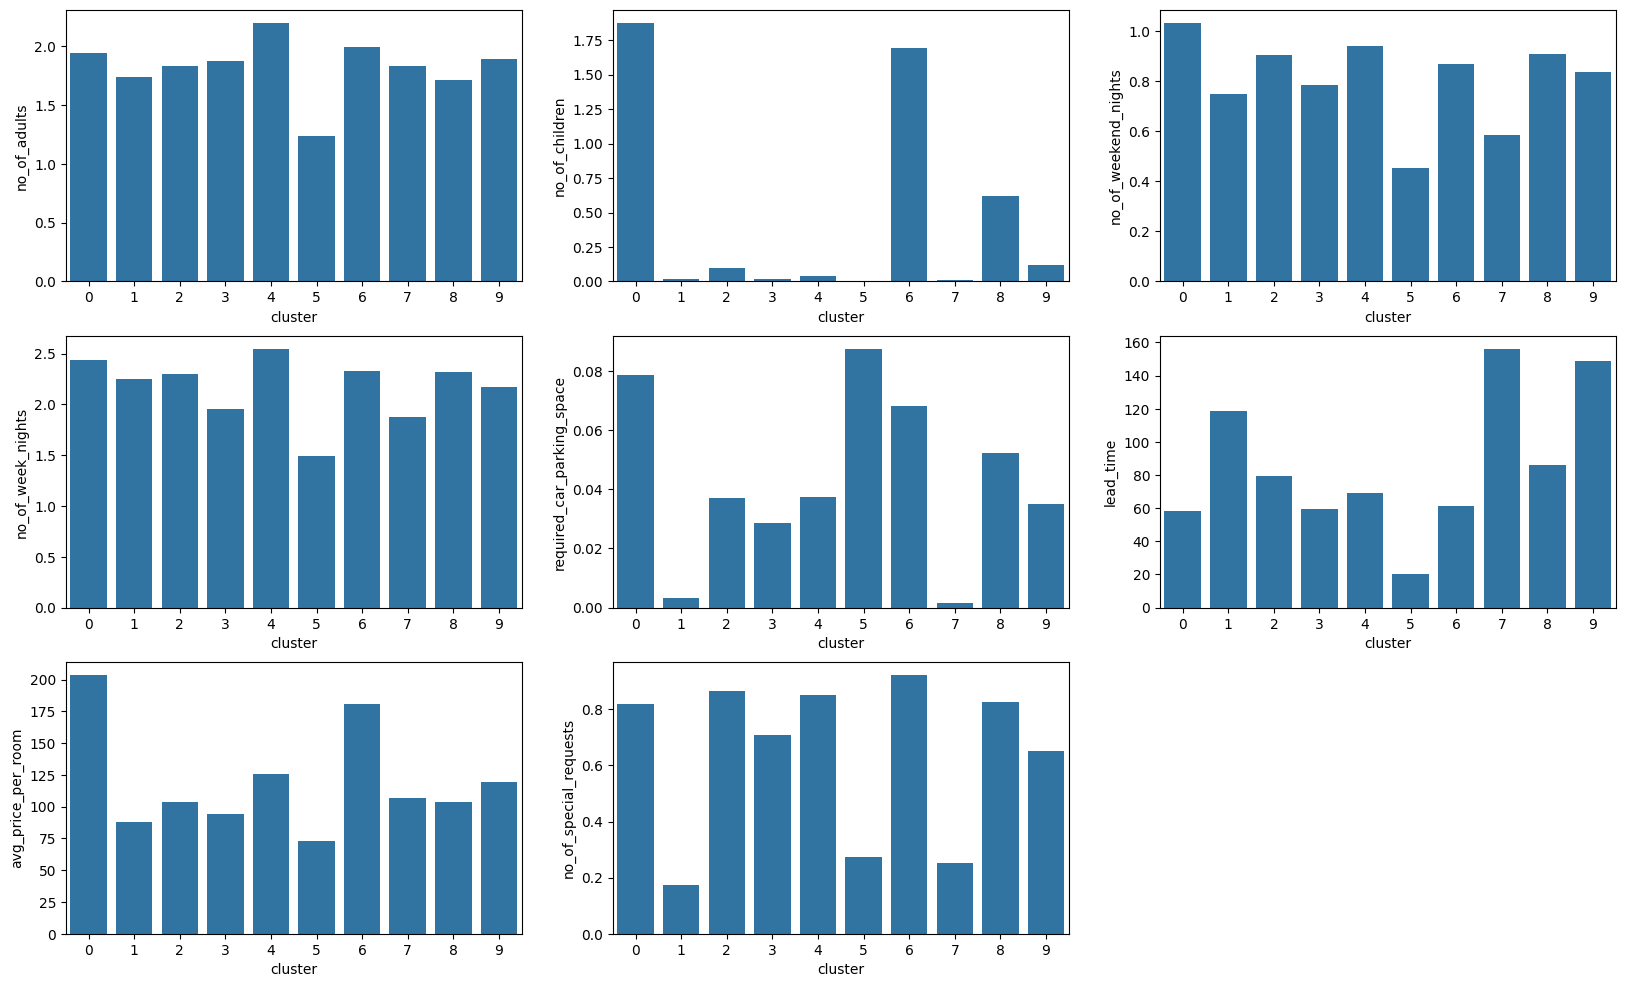

In [38]:

plt.figure(figsize=(20, 12))

plt.subplot(3,3,1)
temp = pd.DataFrame(data.groupby('cluster')['no_of_adults'].mean()).reset_index()
sns.barplot(x = 'cluster',y = 'no_of_adults', data = temp)

plt.subplot(3,3,2)
temp = pd.DataFrame(data.groupby('cluster')['no_of_children'].mean()).reset_index()
sns.barplot(x = 'cluster',y = 'no_of_children', data = temp)

plt.subplot(3,3,3)
temp = pd.DataFrame(data.groupby('cluster')['no_of_weekend_nights'].mean()).reset_index()
sns.barplot(x = 'cluster',y = 'no_of_weekend_nights',data = temp)

plt.subplot(3,3,4)
temp = pd.DataFrame(data.groupby('cluster')['no_of_week_nights'].mean()).reset_index()
sns.barplot(x = 'cluster',y = 'no_of_week_nights', data = temp)

plt.subplot(3,3,5)
temp = pd.DataFrame(data.groupby('cluster')['required_car_parking_space'].mean()).reset_index()
sns.barplot(x = 'cluster',y = 'required_car_parking_space', data = temp)

plt.subplot(3,3,6)
temp = pd.DataFrame(data.groupby('cluster')['lead_time'].mean()).reset_index()
sns.barplot(x = 'cluster',y = 'lead_time',data = temp)

plt.subplot(3,3,7)
temp = pd.DataFrame(data.groupby('cluster')['avg_price_per_room'].mean()).reset_index()
sns.barplot(x = 'cluster',y = 'avg_price_per_room', data = temp)

plt.subplot(3,3,8)
temp = pd.DataFrame(data.groupby('cluster')['no_of_special_requests'].mean()).reset_index()
sns.barplot(x = 'cluster',y = 'no_of_special_requests', data = temp)

plt.show()

In [38]:
# Check frequency of categorical features across clusters

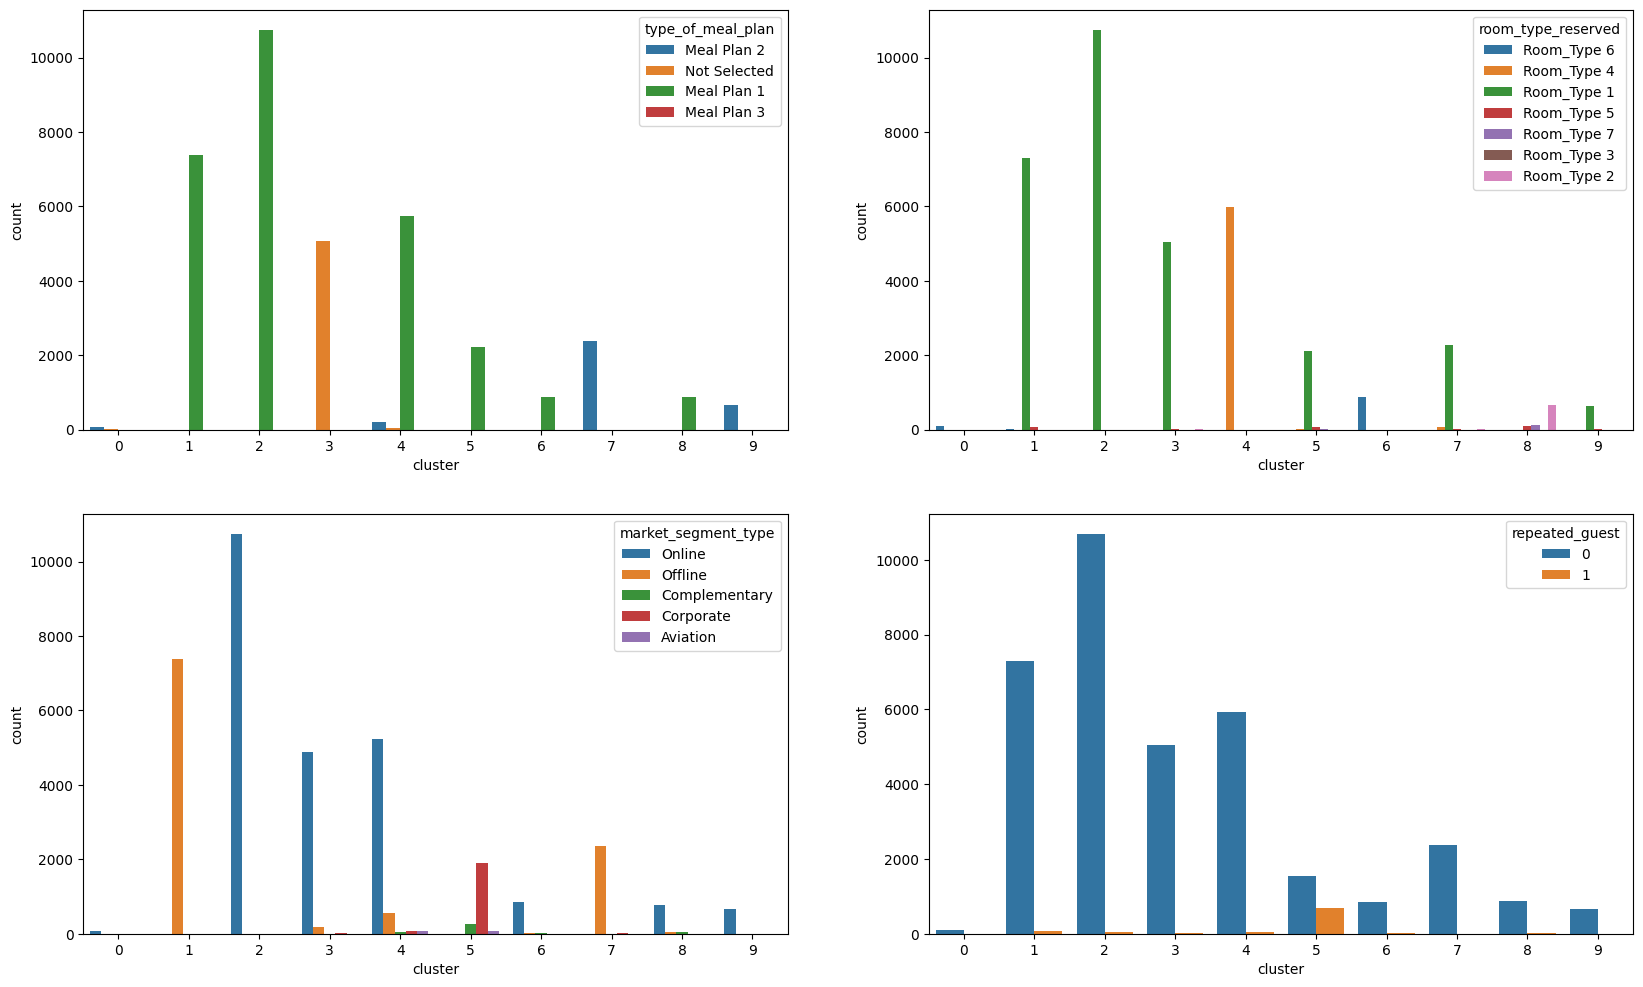

In [39]:

plt.figure(figsize=(20, 12))

plt.subplot(2,2,1)
sns.countplot(x='cluster', hue='type_of_meal_plan', data=data)

plt.subplot(2,2,2)
sns.countplot(x='cluster', hue='room_type_reserved', data=data)

plt.subplot(2,2,3)
sns.countplot(x='cluster', hue='market_segment_type', data=data)

plt.subplot(2,2,4)
sns.countplot(x='cluster', hue='repeated_guest', data=data)

plt.show()

# Elbow curve ( should be done before finalizing clusters)

In [40]:
from sklearn.cluster import KMeans
wcss = [] 

for i in range(2, 30): 
    kmeans = KMeans(n_clusters = i, init = 'k-means++', n_init= 'auto', random_state = 42)
    kmeans.fit(x_train_copy) 
    wcss.append(kmeans.inertia_)

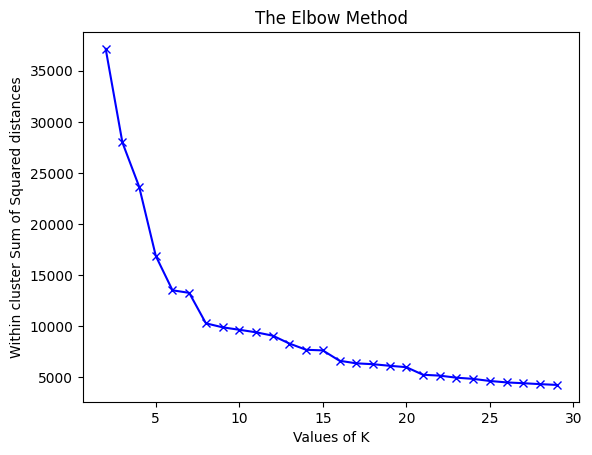

In [41]:
import matplotlib.pyplot as plt
K = range(2, 30)
plt.plot(K, wcss, 'bx-')
plt.xlabel('Values of K')
plt.ylabel('Within cluster Sum of Squared distances')
plt.title('The Elbow Method')
plt.show()

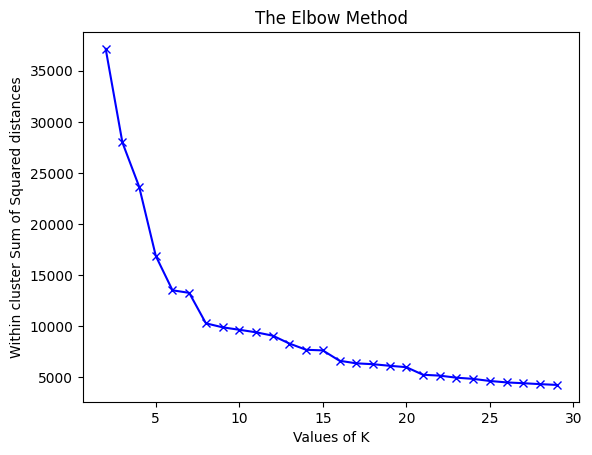

In [42]:
import matplotlib.pyplot as plt
K = range(2, 30)
plt.plot(K, wcss, 'bx-')
plt.xlabel('Values of K')
plt.ylabel('Within cluster Sum of Squared distances')
plt.title('The Elbow Method')
plt.show()
